# Task 2 — Autoformer

The model and training loop are ported from the official implementation
**https://github.com/thuml/Autoformer** (Wu et al., 2021):

| This notebook | Ported from |
| --- | --- |
| `TokenEmbedding`, `TimeFeatureEmbedding`, `DataEmbedding_wo_pos` | `layers/Embed.py` |
| `AutoCorrelation`, `AutoCorrelationLayer` | `layers/AutoCorrelation.py` |
| `my_Layernorm`, `moving_avg`, `series_decomp`, `EncoderLayer`, `Encoder`, `DecoderLayer`, `Decoder` | `layers/Autoformer_EncDec.py` |
| `Model` (Autoformer) | `models/Autoformer.py` |
| training loop, `vali`, decoder input `dec_inp` | `exp/exp_main.py` |
| `adjust_learning_rate` (type1), `EarlyStopping` | `utils/tools.py` |

Code is kept line-for-line where possible. **Adaptations** (each marked `# ADAPTED` in the code):
1. **No timestamps** in this series, so there is no calendar time-feature embedding. The repo's
   known-in-advance input `x_mark` (normally time features, embedded by `TimeFeatureEmbedding`)
   is used for the **external variables** A–J instead. Like time features, they are known for the
   label part *and* the 168 future steps, so the decoder sees the future external values.
2. `TimeFeatureEmbedding` takes the number of external variables as input size (the repo uses
   `freq_map[freq]` = number of time features).
3. `EarlyStopping` keeps the best weights in memory instead of writing `checkpoint.pth`.
4. Data windows are built from the arrays directly (same `seq_x / seq_y / seq_x_mark / seq_y_mark`
   layout as `data_provider/data_loader.py`), with a chronological train / vali / test split.

Hyper-parameters follow `run.py` defaults except where noted in the configuration cell.

In [2]:
# ============================================================
# Setup
# ============================================================
!nvidia-smi

import math
import random
import time
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Sun Oct  4 18:08:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# Upload the three CSV files (or mount Drive and change DATA_DIR)
# ============================================================
from google.colab import files
uploaded = files.upload()

Saving optional_external_data.csv to optional_external_data.csv
Saving student_train.csv to student_train.csv
Saving student_test.csv to student_test.csv


In [4]:
# ============================================================
# Load data
# ============================================================
DATA_DIR = "/content"

train_df = pd.read_csv(f"{DATA_DIR}/student_train.csv")
external_df = pd.read_csv(f"{DATA_DIR}/optional_external_data.csv")

y = train_df["value"].to_numpy(np.float32)                                  # 43,656 observed
X_ext = external_df.drop(columns="time_idx").to_numpy(np.float32)           # 43,824 x 10
feature_names = [c for c in external_df.columns if c != "time_idx"]

print("target:", y.shape, "| external:", X_ext.shape, feature_names)

target: (43656,) | external: (43824, 10) ['feature_A', 'feature_B', 'feature_C', 'feature_D', 'feature_E', 'feature_F', 'feature_G', 'feature_H', 'feature_I', 'feature_J']


In [5]:
# ============================================================
# Configuration
# ============================================================
PRED_LEN = 168                  # required horizon
SEQ_LEN = 168                   # encoder input (one week; memory fades after ~2-3 days)
LABEL_LEN = 48                  # run.py default

# Chronological split (repo naming): train | vali (early stopping) | test (reported)
N = len(y)
TEST_SIZE = 6 * PRED_LEN        # last 6 weeks: reported, never used for any choice
VALI_SIZE = 4 * PRED_LEN        # 4 weeks before test: early stopping
TEST_START = N - TEST_SIZE
VALI_START = TEST_START - VALI_SIZE

TRAIN_STRIDE = 1                # every window, as in the repo's Dataset classes
EVAL_STRIDE = 8                 # vali/test forecast origins every 8 steps

SEEDS = [0, 1, 2]

configs = SimpleNamespace(
    # --- run.py defaults ---
    e_layers=2, d_layers=1, moving_avg=25, factor=1, dropout=0.05,
    embed="timeF", activation="gelu", output_attention=False,
    # --- task-specific ---
    seq_len=SEQ_LEN, label_len=LABEL_LEN, pred_len=PRED_LEN,
    enc_in=1, dec_in=1, c_out=1,          # univariate target ('S'); covariates enter via x_mark
    mark_dim=X_ext.shape[1],              # ADAPTED: 10 external variables instead of time features
    # --- smaller than run.py (512 / 8 / 2048): the score penalises parameters and our
    #     earlier validation showed width 32-64 is enough for this series ---
    d_model=64, n_heads=4, d_ff=256,
)

train_args = SimpleNamespace(            # run.py defaults
    learning_rate=1e-4, batch_size=32, train_epochs=10, patience=3, lradj="type1",
)

print(f"train targets < {VALI_START} | vali {VALI_START}-{TEST_START} | test {TEST_START}-{N}")

train targets < 41976 | vali 41976-42648 | test 42648-43656


In [6]:
# ============================================================
# Scaling (StandardScaler fitted on the training part only, as in the repo)
# ============================================================
y_mean, y_std = float(y[:VALI_START].mean()), float(y[:VALI_START].std())
y_scaled = ((y - y_mean) / y_std).astype(np.float32)

x_mean, x_std = X_ext[:VALI_START].mean(0), X_ext[:VALI_START].std(0)
x_std[x_std < 1e-6] = 1.0
X_scaled = ((X_ext - x_mean) / x_std).astype(np.float32)


def inverse_transform(z):
    """Scaled target -> original units (clipped at 0: the target is non-negative)."""
    return np.clip(z * y_std + y_mean, 0, None)

In [7]:
# ============================================================
# Windows: same layout as data_provider/data_loader.py
#   seq_x      = target[s_begin:s_end]                (encoder input)
#   seq_y      = target[r_begin:r_end]                (label_len known + pred_len future)
#   seq_x_mark = marks[s_begin:s_end]                 (external variables, encoder)
#   seq_y_mark = marks[r_begin:r_end]                 (external variables, label + FUTURE)
# ============================================================
class WindowDataset(Dataset):
    def __init__(self, target, marks, target_start, target_end, stride):
        """All windows whose forecast targets lie inside [target_start, target_end)."""
        self.target, self.marks = target, marks
        first = target_start - SEQ_LEN
        last = target_end - SEQ_LEN - PRED_LEN
        self.starts = list(range(first, last + 1, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, index):
        s_begin = self.starts[index]
        s_end = s_begin + SEQ_LEN
        r_begin = s_end - LABEL_LEN
        r_end = r_begin + LABEL_LEN + PRED_LEN
        seq_x = self.target[s_begin:s_end, None]
        seq_y = self.target[r_begin:r_end, None]
        seq_x_mark = self.marks[s_begin:s_end]
        seq_y_mark = self.marks[r_begin:r_end]
        return seq_x, seq_y, seq_x_mark, seq_y_mark


def make_marks(use_external):
    """Known-in-advance inputs: the 10 external variables, or nothing (ablation)."""
    return X_scaled if use_external else np.zeros((len(X_scaled), 0), np.float32)

In [8]:
# ============================================================
# layers/Embed.py
# ============================================================
class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        padding = 1                                   # torch >= 1.5
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model,
                                   kernel_size=3, padding=padding, padding_mode='circular', bias=False)
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')

    def forward(self, x):
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x


class TimeFeatureEmbedding(nn.Module):
    def __init__(self, d_model, d_inp):
        super(TimeFeatureEmbedding, self).__init__()
        # ADAPTED: d_inp = number of external variables (repo: freq_map[freq] time features)
        self.embed = nn.Linear(d_inp, d_model, bias=False)

    def forward(self, x):
        return self.embed(x)


class DataEmbedding_wo_pos(nn.Module):
    def __init__(self, c_in, d_model, mark_dim, dropout=0.1):
        super(DataEmbedding_wo_pos, self).__init__()
        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        # ADAPTED: marks are the external variables; with mark_dim = 0 (ablation) there is
        # no known-in-advance input. (The repo also builds a PositionalEmbedding here but
        # never uses it in forward; it has no parameters, so it is omitted.)
        self.temporal_embedding = TimeFeatureEmbedding(d_model, mark_dim) if mark_dim > 0 else None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = self.value_embedding(x)
        if self.temporal_embedding is not None:
            x = x + self.temporal_embedding(x_mark)
        return self.dropout(x)

In [9]:
# ============================================================
# layers/AutoCorrelation.py
# ============================================================
class AutoCorrelation(nn.Module):
    """
    AutoCorrelation Mechanism with the following two phases:
    (1) period-based dependencies discovery
    (2) time delay aggregation
    This block can replace the self-attention family mechanism seamlessly.
    """
    def __init__(self, mask_flag=True, factor=1, scale=None, attention_dropout=0.1, output_attention=False):
        super(AutoCorrelation, self).__init__()
        self.factor = factor
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def time_delay_agg_training(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the training phase.
        """
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        index = torch.topk(torch.mean(mean_value, dim=0), top_k, dim=-1)[1]
        weights = torch.stack([mean_value[:, index[i]] for i in range(top_k)], dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            pattern = torch.roll(tmp_values, -int(index[i]), -1)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def time_delay_agg_inference(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the inference phase.
        """
        batch = values.shape[0]
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # index init
        init_index = torch.arange(length).unsqueeze(0).unsqueeze(0).unsqueeze(0)\
            .repeat(batch, head, channel, 1).to(values.device)
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        weights, delay = torch.topk(mean_value, top_k, dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values.repeat(1, 1, 1, 2)
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            tmp_delay = init_index + delay[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length)
            pattern = torch.gather(tmp_values, dim=-1, index=tmp_delay)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def forward(self, queries, keys, values, attn_mask):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        if L > S:
            zeros = torch.zeros_like(queries[:, :(L - S), :]).float()
            values = torch.cat([values, zeros], dim=1)
            keys = torch.cat([keys, zeros], dim=1)
        else:
            values = values[:, :L, :, :]
            keys = keys[:, :L, :, :]

        # period-based dependencies
        q_fft = torch.fft.rfft(queries.permute(0, 2, 3, 1).contiguous(), dim=-1)
        k_fft = torch.fft.rfft(keys.permute(0, 2, 3, 1).contiguous(), dim=-1)
        res = q_fft * torch.conj(k_fft)
        corr = torch.fft.irfft(res, n=L, dim=-1)

        # time delay agg
        if self.training:
            V = self.time_delay_agg_training(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)
        else:
            V = self.time_delay_agg_inference(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)

        if self.output_attention:
            return (V.contiguous(), corr.permute(0, 3, 1, 2))
        else:
            return (V.contiguous(), None)


class AutoCorrelationLayer(nn.Module):
    def __init__(self, correlation, d_model, n_heads, d_keys=None,
                 d_values=None):
        super(AutoCorrelationLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_correlation = correlation
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_correlation(
            queries,
            keys,
            values,
            attn_mask
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), attn

In [10]:
# ============================================================
# layers/Autoformer_EncDec.py
# ============================================================
class my_Layernorm(nn.Module):
    """
    Special designed layernorm for the seasonal part
    """
    def __init__(self, channels):
        super(my_Layernorm, self).__init__()
        self.layernorm = nn.LayerNorm(channels)

    def forward(self, x):
        x_hat = self.layernorm(x)
        bias = torch.mean(x_hat, dim=1).unsqueeze(1).repeat(1, x.shape[1], 1)
        return x_hat - bias


class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean


class EncoderLayer(nn.Module):
    """
    Autoformer encoder layer with the progressive decomposition architecture
    """
    def __init__(self, attention, d_model, d_ff=None, moving_avg=25, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(
            x, x, x,
            attn_mask=attn_mask
        )
        x = x + self.dropout(new_x)
        x, _ = self.decomp1(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        res, _ = self.decomp2(x + y)
        return res, attn


class Encoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None):
        attns = []
        if self.conv_layers is not None:
            for attn_layer, conv_layer in zip(self.attn_layers, self.conv_layers):
                x, attn = attn_layer(x, attn_mask=attn_mask)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


class DecoderLayer(nn.Module):
    """
    Autoformer decoder layer with the progressive decomposition architecture
    """
    def __init__(self, self_attention, cross_attention, d_model, c_out, d_ff=None,
                 moving_avg=25, dropout=0.1, activation="relu"):
        super(DecoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.decomp3 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.projection = nn.Conv1d(in_channels=d_model, out_channels=c_out, kernel_size=3, stride=1, padding=1,
                                    padding_mode='circular', bias=False)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attention(
            x, x, x,
            attn_mask=x_mask
        )[0])
        x, trend1 = self.decomp1(x)
        x = x + self.dropout(self.cross_attention(
            x, cross, cross,
            attn_mask=cross_mask
        )[0])
        x, trend2 = self.decomp2(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        x, trend3 = self.decomp3(x + y)

        residual_trend = trend1 + trend2 + trend3
        residual_trend = self.projection(residual_trend.permute(0, 2, 1)).transpose(1, 2)
        return x, residual_trend


class Decoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, layers, norm_layer=None, projection=None):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None, trend=None):
        for layer in self.layers:
            x, residual_trend = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)
            trend = trend + residual_trend

        if self.norm is not None:
            x = self.norm(x)

        if self.projection is not None:
            x = self.projection(x)
        return x, trend

In [11]:
# ============================================================
# models/Autoformer.py
# ============================================================
class Model(nn.Module):
    """
    Autoformer is the first method to achieve the series-wise connection,
    with inherent O(LlogL) complexity
    """
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.label_len = configs.label_len
        self.pred_len = configs.pred_len
        self.output_attention = configs.output_attention

        # Decomp
        kernel_size = configs.moving_avg
        self.decomp = series_decomp(kernel_size)

        # Embedding
        # The series-wise connection inherently contains the sequential information.
        # Thus, we can discard the position embedding of transformers.
        # ADAPTED: marks = external variables (mark_dim of them) instead of time features
        self.enc_embedding = DataEmbedding_wo_pos(configs.enc_in, configs.d_model, configs.mark_dim,
                                                  configs.dropout)
        self.dec_embedding = DataEmbedding_wo_pos(configs.dec_in, configs.d_model, configs.mark_dim,
                                                  configs.dropout)

        # Encoder
        self.encoder = Encoder(
            [
                EncoderLayer(
                    AutoCorrelationLayer(
                        AutoCorrelation(False, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=configs.output_attention),
                        configs.d_model, configs.n_heads),
                    configs.d_model,
                    configs.d_ff,
                    moving_avg=configs.moving_avg,
                    dropout=configs.dropout,
                    activation=configs.activation
                ) for l in range(configs.e_layers)
            ],
            norm_layer=my_Layernorm(configs.d_model)
        )
        # Decoder
        self.decoder = Decoder(
            [
                DecoderLayer(
                    AutoCorrelationLayer(
                        AutoCorrelation(True, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=False),
                        configs.d_model, configs.n_heads),
                    AutoCorrelationLayer(
                        AutoCorrelation(False, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=False),
                        configs.d_model, configs.n_heads),
                    configs.d_model,
                    configs.c_out,
                    configs.d_ff,
                    moving_avg=configs.moving_avg,
                    dropout=configs.dropout,
                    activation=configs.activation,
                )
                for l in range(configs.d_layers)
            ],
            norm_layer=my_Layernorm(configs.d_model),
            projection=nn.Linear(configs.d_model, configs.c_out, bias=True)
        )

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec,
                enc_self_mask=None, dec_self_mask=None, dec_enc_mask=None):
        # decomp init
        mean = torch.mean(x_enc, dim=1).unsqueeze(1).repeat(1, self.pred_len, 1)
        zeros = torch.zeros([x_dec.shape[0], self.pred_len, x_dec.shape[2]], device=x_enc.device)
        seasonal_init, trend_init = self.decomp(x_enc)
        # decoder input
        trend_init = torch.cat([trend_init[:, -self.label_len:, :], mean], dim=1)
        seasonal_init = torch.cat([seasonal_init[:, -self.label_len:, :], zeros], dim=1)
        # enc
        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=enc_self_mask)
        # dec
        dec_out = self.dec_embedding(seasonal_init, x_mark_dec)
        seasonal_part, trend_part = self.decoder(dec_out, enc_out, x_mask=dec_self_mask, cross_mask=dec_enc_mask,
                                                 trend=trend_init)
        # final
        dec_out = trend_part + seasonal_part

        if self.output_attention:
            return dec_out[:, -self.pred_len:, :], attns
        else:
            return dec_out[:, -self.pred_len:, :]  # [B, L, D]


# Quick check: output shape and trainable parameters
_check = Model(configs)
_x = torch.randn(4, SEQ_LEN, 1); _xm = torch.randn(4, SEQ_LEN, configs.mark_dim)
_xd = torch.zeros(4, LABEL_LEN + PRED_LEN, 1); _xdm = torch.randn(4, LABEL_LEN + PRED_LEN, configs.mark_dim)
print("output:", tuple(_check(_x, _xm, _xd, _xdm).shape),
      "| trainable parameters:", sum(p.numel() for p in _check.parameters() if p.requires_grad))
del _check

output: (4, 168, 1) | trainable parameters: 167041


In [12]:
# ============================================================
# utils/tools.py + exp/exp_main.py (training loop)
# ============================================================
def adjust_learning_rate(optimizer, epoch, args):
    if args.lradj == 'type1':
        lr_adjust = {epoch: args.learning_rate * (0.5 ** ((epoch - 1) // 1))}
    elif args.lradj == 'type2':
        lr_adjust = {
            2: 5e-5, 4: 1e-5, 6: 5e-6, 8: 1e-6,
            10: 5e-7, 15: 1e-7, 20: 5e-8
        }
    if epoch in lr_adjust.keys():
        lr = lr_adjust[epoch]
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr


class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.best_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        # ADAPTED: keep the best weights in memory instead of writing checkpoint.pth
        self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        self.val_loss_min = val_loss


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def model_step(model, batch_x, batch_y, batch_x_mark, batch_y_mark):
    """exp_main: decoder input = label_len known values + pred_len zeros."""
    batch_x = batch_x.float().to(device)
    batch_y = batch_y.float().to(device)
    batch_x_mark = batch_x_mark.float().to(device)
    batch_y_mark = batch_y_mark.float().to(device)

    dec_inp = torch.zeros_like(batch_y[:, -PRED_LEN:, :]).float()
    dec_inp = torch.cat([batch_y[:, :LABEL_LEN, :], dec_inp], dim=1).float().to(device)
    outputs = model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

    f_dim = 0                                          # features = 'S'
    outputs = outputs[:, -PRED_LEN:, f_dim:]
    batch_y = batch_y[:, -PRED_LEN:, f_dim:]
    return outputs, batch_y


def vali(model, loader, criterion):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y, batch_x_mark, batch_y_mark in loader:
            outputs, batch_y = model_step(model, batch_x, batch_y, batch_x_mark, batch_y_mark)
            total_loss.append(criterion(outputs, batch_y).item())
    model.train()
    return np.average(total_loss)


def predict_original_units(model, loader):
    """Forecasts for every window of a loader, in original units."""
    model.eval()
    outputs_all = []
    with torch.no_grad():
        for batch_x, batch_y, batch_x_mark, batch_y_mark in loader:
            outputs, _ = model_step(model, batch_x, batch_y, batch_x_mark, batch_y_mark)
            outputs_all.append(outputs[..., 0].cpu().numpy())
    return inverse_transform(np.concatenate(outputs_all))


def actual_values(dataset):
    return np.stack([y[s + SEQ_LEN:s + SEQ_LEN + PRED_LEN] for s in dataset.starts])


def metrics(prediction, actual):
    error = prediction - actual
    denominator = np.abs(actual) + np.abs(prediction)
    smape = np.where(denominator > 0, 2 * np.abs(error) / np.where(denominator > 0, denominator, 1), 0)
    return {"RMSE": float(np.sqrt(np.mean(error ** 2))), "MAE": float(np.mean(np.abs(error))),
            "sMAPE": float(100 * smape.mean())}


def train_one(seed, use_external):
    """exp_main.train for one seed: Adam, MSE, early stopping on vali, type1 lr schedule."""
    set_seed(seed)
    marks = make_marks(use_external)
    run_configs = SimpleNamespace(**{**vars(configs), "mark_dim": marks.shape[1]})

    train_data = WindowDataset(y_scaled, marks, SEQ_LEN, VALI_START, TRAIN_STRIDE)
    vali_data = WindowDataset(y_scaled, marks, VALI_START, TEST_START, EVAL_STRIDE)
    test_data = WindowDataset(y_scaled, marks, TEST_START, N, EVAL_STRIDE)

    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_data, batch_size=train_args.batch_size, shuffle=True,
                              drop_last=True, generator=generator, num_workers=2)
    vali_loader = DataLoader(vali_data, batch_size=train_args.batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=train_args.batch_size, shuffle=False)

    model = Model(run_configs).float().to(device)
    early_stopping = EarlyStopping(patience=train_args.patience, verbose=True)
    model_optim = torch.optim.Adam(model.parameters(), lr=train_args.learning_rate)
    criterion = nn.MSELoss()

    epochs_run = 0
    for epoch in range(train_args.train_epochs):
        epoch_time = time.time()
        train_loss = []
        model.train()
        for batch_x, batch_y, batch_x_mark, batch_y_mark in train_loader:
            model_optim.zero_grad()
            outputs, batch_y = model_step(model, batch_x, batch_y, batch_x_mark, batch_y_mark)
            loss = criterion(outputs, batch_y)
            train_loss.append(loss.item())
            loss.backward()
            model_optim.step()

        epochs_run = epoch + 1
        train_loss = np.average(train_loss)
        vali_loss = vali(model, vali_loader, criterion)
        test_loss = vali(model, test_loader, criterion)
        print(f"  epoch {epoch + 1:2d} | train {train_loss:.4f} | vali {vali_loss:.4f} | "
              f"test {test_loss:.4f} | {time.time() - epoch_time:.0f}s", flush=True)
        early_stopping(vali_loss, model)
        if early_stopping.early_stop:
            print("  early stopping")
            break
        adjust_learning_rate(model_optim, epoch + 1, train_args)

    model.load_state_dict(early_stopping.best_state)
    test_pred = predict_original_units(model, test_loader)
    test_actual = actual_values(test_data)
    return {"seed": seed, "use_external": use_external, "model": model, "marks": marks,
            "epochs_run": epochs_run,
            "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
            "test_pred": test_pred, "test_actual": test_actual,
            **{f"test {k}": v for k, v in metrics(test_pred, test_actual).items()}}

In [13]:
# ============================================================
# Experiments: with / without the external file, several seeds
# ============================================================
runs = []
for use_external in (True, False):
    for seed in SEEDS:
        print(f"external={use_external}  seed={seed}", flush=True)
        start = time.time()
        run = train_one(seed, use_external)
        runs.append(run)
        print(f"  -> test RMSE {run['test RMSE']:.2f}  MAE {run['test MAE']:.2f}  "
              f"sMAPE {run['test sMAPE']:.1f}  epochs {run['epochs_run']}  "
              f"{time.time() - start:.0f}s\n", flush=True)

external=True  seed=0
  epoch  1 | train 0.8480 | vali 1.1509 | test 0.9221 | 49s
  epoch  2 | train 0.6815 | vali 1.0910 | test 0.9253 | 43s
  epoch  3 | train 0.6239 | vali 1.0122 | test 0.8853 | 44s
  epoch  4 | train 0.5900 | vali 1.0094 | test 0.8124 | 44s
  epoch  5 | train 0.5779 | vali 1.0557 | test 0.8379 | 44s
  epoch  6 | train 0.5731 | vali 1.0519 | test 0.8392 | 43s
  epoch  7 | train 0.5699 | vali 1.0382 | test 0.8312 | 44s
  early stopping
  -> test RMSE 86.21  MAE 70.84  sMAPE 82.8  epochs 7  318s

external=True  seed=1
  epoch  1 | train 0.8511 | vali 1.5902 | test 0.9050 | 43s
  epoch  2 | train 0.6959 | vali 1.3893 | test 0.8653 | 44s
  epoch  3 | train 0.6460 | vali 1.2905 | test 0.8477 | 47s
  epoch  4 | train 0.6264 | vali 1.2541 | test 0.8481 | 44s
  epoch  5 | train 0.6168 | vali 1.2444 | test 0.8432 | 44s
  epoch  6 | train 0.6128 | vali 1.2431 | test 0.8429 | 43s
  epoch  7 | train 0.6098 | vali 1.2765 | test 0.8406 | 44s
  epoch  8 | train 0.6101 | vali 1.251

,model,seed RMSEs,mean ± std,ensemble RMSE,ensemble MAE,ensemble sMAPE,P (total),E (total)
0,historical mean (baseline),-,-,116.00,92.65,98.03,0,0
1,Autoformer + external,"86.21, 85.82, 87.51",86.51 ± 0.72,81.48,64.46,76.44,501123,21
2,"Autoformer, no external","125.72, 126.71, 124.63",125.69 ± 0.85,124.93,101.53,99.99,497283,26


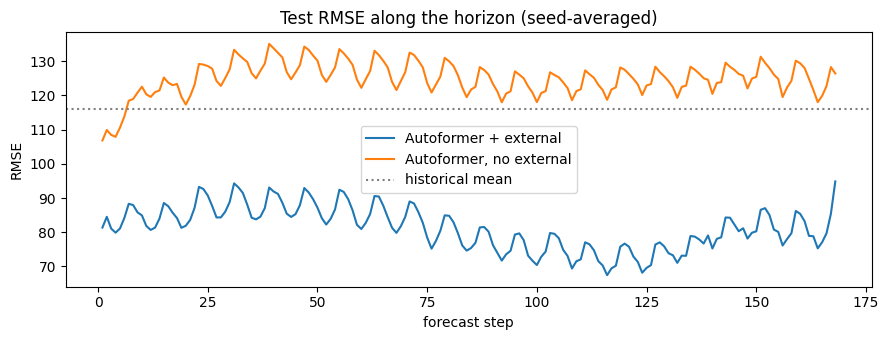

Final configuration: with external


In [14]:
# ============================================================
# Results: single seeds vs seed average; with vs without external data
# ============================================================
test_actual = runs[0]["test_actual"]
historical_mean = float(y[:VALI_START].mean())

rows = [{"model": "historical mean (baseline)", "seed RMSEs": "-", "mean ± std": "-",
         **{f"ensemble {k}": round(v, 2) for k, v in
            metrics(np.full_like(test_actual, historical_mean), test_actual).items()},
         "P (total)": 0, "E (total)": 0}]
ensemble_predictions = {}
for use_external in (True, False):
    group = [r for r in runs if r["use_external"] == use_external]
    seed_rmse = [r["test RMSE"] for r in group]
    ensemble_predictions[use_external] = np.mean([r["test_pred"] for r in group], axis=0)
    rows.append({
        "model": "Autoformer + external" if use_external else "Autoformer, no external",
        "seed RMSEs": ", ".join(f"{v:.2f}" for v in seed_rmse),
        "mean ± std": f"{np.mean(seed_rmse):.2f} ± {np.std(seed_rmse):.2f}",
        **{f"ensemble {k}": round(v, 2) for k, v in
           metrics(ensemble_predictions[use_external], test_actual).items()},
        "P (total)": sum(r["params"] for r in group),
        "E (total)": sum(r["epochs_run"] for r in group),
    })

results = pd.DataFrame(rows)
display(results)
results.to_csv("thuml_autoformer_results.csv", index=False)

# Error along the 168-step horizon (test period, seed-averaged forecasts)
plt.figure(figsize=(9, 3.5))
for use_external, label in ((True, "Autoformer + external"), (False, "Autoformer, no external")):
    horizon_rmse = np.sqrt(((ensemble_predictions[use_external] - test_actual) ** 2).mean(axis=0))
    plt.plot(np.arange(1, PRED_LEN + 1), horizon_rmse, label=label)
plt.axhline(metrics(np.full_like(test_actual, historical_mean), test_actual)["RMSE"],
            color="grey", ls=":", label="historical mean")
plt.xlabel("forecast step"); plt.ylabel("RMSE"); plt.legend()
plt.title("Test RMSE along the horizon (seed-averaged)")
plt.tight_layout(); plt.savefig("thuml_horizon_rmse.png", dpi=150); plt.show()

USE_EXTERNAL_FINAL = min((True, False), key=lambda u: metrics(ensemble_predictions[u], test_actual)["RMSE"])
print("Final configuration:", "with external" if USE_EXTERNAL_FINAL else "without external")

In [15]:
# ============================================================
# Final forecast: time_idx 43657 ... 43824 (seed-averaged)
# ============================================================
final_members = [r for r in runs if r["use_external"] == USE_EXTERNAL_FINAL]

member_forecasts = []
for r in final_members:
    marks = r["marks"]
    batch_x = torch.tensor(y_scaled[N - SEQ_LEN:N, None]).unsqueeze(0)
    batch_x_mark = torch.tensor(marks[N - SEQ_LEN:N]).unsqueeze(0)
    # seq_y: label_len known values + pred_len placeholders (zeroed by model_step anyway)
    batch_y = torch.tensor(np.concatenate([y_scaled[N - LABEL_LEN:N],
                                           np.zeros(PRED_LEN, np.float32)])[:, None]).unsqueeze(0)
    batch_y_mark = torch.tensor(marks[N - LABEL_LEN:N + PRED_LEN]).unsqueeze(0)  # future marks known
    r["model"].eval()
    with torch.no_grad():
        outputs, _ = model_step(r["model"], batch_x, batch_y, batch_x_mark, batch_y_mark)
    member_forecasts.append(inverse_transform(outputs[0, :, 0].cpu().numpy()))

forecast = np.mean(member_forecasts, axis=0)
assert forecast.shape == (PRED_LEN,) and np.isfinite(forecast).all()

forecast_df = pd.DataFrame({"time_idx": np.arange(N + 1, N + PRED_LEN + 1), "value": forecast})
forecast_df.to_csv("forecast_168_thuml.csv", index=False)
submission_line = ", ".join(f"{v:.4f}" for v in forecast)
with open("forecast_168_thuml.txt", "w") as f:
    f.write(submission_line)

P = sum(r["params"] for r in final_members)
E = sum(r["epochs_run"] for r in final_members)
print(f"{len(final_members)} seeds, {'with' if USE_EXTERNAL_FINAL else 'without'} external data")
print(f"test RMSE of this ensemble: {metrics(ensemble_predictions[USE_EXTERNAL_FINAL], test_actual)['RMSE']:.2f}")
print(f"time_idx {forecast_df.time_idx.iloc[0]} .. {forecast_df.time_idx.iloc[-1]} | "
      f"min {forecast.min():.1f} mean {forecast.mean():.1f} max {forecast.max():.1f}")
print(f"\nDeclare: P = {P} trainable parameters, E = {E} epochs")
print("\nPaste this on the leaderboard:\n")
print(submission_line)

# from google.colab import files
# files.download("forecast_168_thuml.txt"); files.download("forecast_168_thuml.csv")

3 seeds, with external data
test RMSE of this ensemble: 81.48
time_idx 43657 .. 43824 | min 0.3 mean 112.1 max 173.0

Declare: P = 501123 trainable parameters, E = 21 epochs

Paste this on the leaderboard:

25.2953, 27.6246, 27.2924, 36.6380, 40.0076, 47.1679, 61.1978, 65.9005, 67.0382, 65.6392, 67.3106, 67.0397, 72.8621, 74.0140, 77.5100, 84.3975, 96.9810, 111.7017, 122.4116, 130.7077, 131.5526, 138.4430, 137.5238, 143.8936, 149.3374, 153.7757, 157.7839, 153.7984, 152.8738, 155.4556, 155.5154, 154.3210, 146.6013, 151.4865, 148.8084, 147.5711, 147.6115, 149.4851, 155.4619, 155.6467, 154.8605, 154.6928, 152.8950, 147.9960, 144.2677, 146.3942, 144.9966, 139.2676, 128.7725, 125.3553, 125.0907, 121.4004, 121.2249, 123.2664, 128.1865, 129.7753, 127.9378, 135.8844, 137.3164, 136.8591, 137.9072, 141.2009, 142.4611, 145.5566, 151.1368, 155.6362, 158.5183, 167.2246, 173.0163, 171.2614, 172.8938, 166.6330, 162.7897, 156.3366, 156.7800, 151.7977, 146.8361, 141.2421, 132.8689, 128.3884, 127.6687, 